В данном ноутбуке предлагается итоговый сравнительный анализ используемых в uplift-моделировании классических ml-подходов. Помимо обучения самих моделей, с помощью изотонической регрессии осуществляется калибровка для сопоставления результатов в контексте задачи вероятностного моделирования (и более точное моделирования под вероятностный таргет).        

Данный ноутбук является логическим продолжением поиска оптимальной модели, предыдущий этап которого показан в ноутбуке Models-vs-baseline_ananlysis. В текущей итерации проекта было дополнено признаковое пространство как новыми фичами, выведенными исходя из бизнес-задачи uplift, так и кластеризацией по численному признаковому пространству, успешно доказавшей свою состоятельность в анализе, проведенном в ноутбуке Feature_clusterization. Также в анализируемый список моделей был добавлен класс UpliftRandomForest.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict

import umap
from scipy.spatial.distance import cdist
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import DBSCAN, KMeans
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.calibration import CalibratedClassifierCV

from catboost import CatBoostClassifier, CatBoostRegressor
from causalml.inference.tree import UpliftRandomForestClassifier
from sklift.datasets import fetch_x5
from sklift.models import TwoModels
from sklift.metrics import (
    uplift_auc_score, qini_auc_score, uplift_at_k, weighted_average_uplift
)
import sklearn.utils
def dummy_check_matplotlib_support(*args, **kwargs):
    pass
sklearn.utils.check_matplotlib_support = dummy_check_matplotlib_support

from sklift.viz import plot_qini_curve, plot_uplift_curve

# Настройки графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

if parent_dir not in os.sys.path:
    os.sys.path.append(parent_dir)

from extractors.feature_extraction_expanded import *
from extractors.models_extraction import *
from extractors.clusterization_features_extraction import *

In [2]:
dataset = fetch_x5()
data = dataset.data

In [3]:
extractor = UpliftFeatureExtractorExpanded(drop_redundant=True)
df = extractor.calculate_features(
    clients_df=data.clients,
    train_df=data.train,
    treatment_df=dataset.treatment,
    target_df=dataset.target,
    purchases_df=data.purchases
)

del data, dataset
gc.collect()

features = extractor.feature_names
TARGET_COL = "target"
TREATMENT_COL = "treatment_flg"

X_all = df[features].copy()
y_all = df[TARGET_COL].values
t_all = df[TREATMENT_COL].values

print(f"Размер итогового датасета: {X_all.shape}")

Размер итогового датасета: (200039, 45)


По сравнению с прошлой версией UpliftFeatureExtractor, исходя из инсайтов, полученно в предыдущей итерации анализа моделирования, были изменены и добавлены следующие признаки:     

1. Поведенческие профили (Shopping Style)       
weekend_purchase_ratio - доля покупок в выходные (суббота/воскресенье).     
evening_purchase_ratio - доля покупок в вечернее время (18:00–23:59).       
store_concentration - насколько клиент предан одному конкретному магазину.      
purchase_time_variance - стабильность времени посещения магазина (разброс часов).         

2. Эффективность корзины и баллов           
product_diversity - разнообразие товаров (уникальные / общее кол-во).       
avg_price_per_product - средний чек за одну единицу товара.     
avg_days_between_purchases - средний цикл жизни клиента (интервал между визитами).       
express_points_ratio - доля «акционных» (экспресс) баллов.      
points_redemption_rate - насколько активно клиент тратит накопленные баллы.       
points_efficiency - сколько баллов клиент извлекает из каждого потраченного рубля.         

3. Бизнес-сегментация (Tiers)           
purchase_frequency_tier - сегментация по частоте (low, medium, high).           
store_loyalty_tier - сегментация по лояльности к торговой точке.        
age_group - возрастные когорты (young, middle, senior, elderly).        
is_activated_and_loyal - флаг «ядра» аудитории (активирован + высокая лояльность).            

In [4]:
def calculate_metrics(y_true, uplift_preds, treatment):
    return {
        "AUUC": uplift_auc_score(y_true, uplift_preds, treatment),
        "Qini": qini_auc_score(y_true, uplift_preds, treatment),
        "WAU": weighted_average_uplift(y_true, uplift_preds, treatment),
        "Uplift@10%": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.1),
        "Uplift@20%": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.2),
        "Uplift@30%": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.3),
        "Uplift@50%": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.5)
    }

In [9]:
N_SPLITS = 3
# Стратификация по комбинации тритмента и таргета
strata = df[[TREATMENT_COL, TARGET_COL]].astype(str).agg("_".join, axis=1)
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

В качестве стратегии сопоставления мы обучаем модели на нескольких фолдах, чтобы провести оценку усредненных метрик - так мы гарантируем более обобщенные значения.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV

# Инициализация переменных для графиков
last_fold_preds = {}
last_fold_y = None
last_fold_t = None

results_list = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_all, strata)):
    print(f"--- Fold {fold + 1} ---")
    
    # Разделение
    X_train, X_test = X_all.iloc[train_idx].copy(), X_all.iloc[test_idx].copy()
    y_train, y_test = y_all[train_idx], y_all[test_idx]
    t_train, t_test = t_all[train_idx], t_all[test_idx]
    
    # Кластеризация
    current_num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
    clusterizer = UmapClusterTransformer(num_cols=current_num_cols, n_clusters=5)
    
    X_train_clust = clusterizer.fit_transform(X_train)
    X_test_clust = clusterizer.transform(X_test)
    
    # Обновляем списки колонок после добавления кластеров
    cat_cols_cl = X_train_clust.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols_cl = X_train_clust.select_dtypes(include=["number"]).columns.tolist()
    
    # T-LEARNER (LogReg)
    t_learner = build_t_learner_logreg(num_cols_cl, cat_cols_cl)
    t_learner.estimator_trmnt = CalibratedClassifierCV(t_learner.estimator_trmnt, method='isotonic', cv=3)
    t_learner.estimator_ctrl = CalibratedClassifierCV(t_learner.estimator_ctrl, method='isotonic', cv=3)
    
    t_learner.fit(X_train_clust, y_train, t_train)
    preds_t = t_learner.predict(X_test_clust)
    results_list.append({"Model": "T-Learner (LogReg)", "Fold": fold+1, **calculate_metrics(y_test, preds_t, t_test)})
    
    # S-LEARNER (CatBoost)
    X_train_s = X_train_clust.copy()
    X_test_s = X_test_clust.copy()
    X_train_s[TREATMENT_COL] = t_train
    X_test_s[TREATMENT_COL] = t_test
    
    cat_cols_s = cat_cols_cl + [TREATMENT_COL] if TREATMENT_COL not in cat_cols_cl else cat_cols_cl
    s_learner_base = build_s_learner_catboost(cat_features=cat_cols_s, use_calibration=True)
    s_learner_calibrated = CalibratedClassifierCV(s_learner_base, method='isotonic', cv=3)
    s_learner_calibrated.fit(X_train_s, y_train)

    preds_s = predict_uplift_s_learner(s_learner_calibrated, X_test_s, TREATMENT_COL)
    results_list.append({"Model": "S-Learner (CatBoost)", "Fold": fold+1, **calculate_metrics(y_test, preds_s, t_test)})
    
    # X-LEARNER (CatBoost)
    x_learner = build_x_learner_catboost(cat_features=cat_cols_cl, use_calibration=True)
    x_learner.outcome_learner = CalibratedClassifierCV(x_learner.outcome_learner, method='isotonic', cv=3)
    x_learner.propensity_learner = CalibratedClassifierCV(x_learner.propensity_learner, method='isotonic', cv=3)
    
    x_learner.fit(X_train_clust, y_train, t_train)
    preds_x = x_learner.predict(X_test_clust)
    results_list.append({"Model": "X-Learner (CatBoost)", "Fold": fold+1, **calculate_metrics(y_test, preds_x, t_test)})
    
    # UPLIFT RANDOM FOREST
    pre_rf = build_preprocessor(num_cols_cl, cat_cols_cl)
    X_train_rf = pre_rf.fit_transform(X_train_clust)
    X_test_rf = pre_rf.transform(X_test_clust)
    
    t_train_str = np.where(t_train == 1, 'treatment', 'control')
    urf = build_uplift_random_forest()
    urf.fit(X=X_train_rf, treatment=t_train_str, y=y_train)
    preds_rf = urf.predict(X_test_rf).flatten()
    results_list.append({"Model": "Uplift RF", "Fold": fold+1, **calculate_metrics(y_test, preds_rf, t_test)})

    if fold == N_SPLITS - 1:
        last_fold_preds = {
            "T-Learner (LogReg)": preds_t,
            "S-Learner (CatBoost)": preds_s,
            "X-Learner (CatBoost)": preds_x,
            "Uplift RF": preds_rf
        }
        last_fold_y = y_test
        last_fold_t = t_test

print("\nОбучение завершено!")

In [11]:
results_df = pd.DataFrame(results_list)
mean_results = results_df.groupby("Model").mean().drop(columns=["Fold"]).reset_index()

print("Средние метрики по фолдам после калибровки")
display(mean_results.style.highlight_max(axis=0, subset=mean_results.columns[1:], color='blue'))

Средние метрики по фолдам после калибровки


,Model,AUUC,Qini,WAU,Uplift@10%,Uplift@20%,Uplift@30%,Uplift@50%
0,S-Learner (CatBoost),0.018513,0.011901,0.033019,0.091334,0.068489,0.056240,0.047851
1,T-Learner (LogReg),0.022013,0.014206,0.032915,0.100731,0.074882,0.064497,0.050371
2,Uplift RF,0.019385,0.012478,0.032961,0.082361,0.067476,0.054795,0.047658
3,X-Learner (CatBoost),0.022422,0.014494,0.033357,0.102326,0.076492,0.066719,0.048917


Почему X-Learner вырвался вперед?

Ранее **T-Learner (LogReg)** показывал небольшое преимущество за счет своей простоты и устойчивости к шуму. Однако текущий стек фичей и калибровка позволили **X-Learner** полностью раскрыть свой потенциал:

1.  **Эффект калибровки:** X-Learner - это мета-алгоритм, который вычисляет псевдо-эффекты на основе разности предсказаний. Без калибровки эти разности были зашумлены из-за смещенных вероятностей. Калибровка выровняла предсказания, сделав расчеты эффектов значительно точнее.
2.  **Синергия CatBoost и кластерных фич:** Новые фичи (расстояния до центроидов UMAP и поведенческие индексы) имеют нелинейную природу. Градиентный бустинг в основе X-Learner извлекает из этих пространственных данных гораздо больше информации, чем логистическая регрессия в T-Learner.
3.  **Propensity:** В обновленной версии X-Learner точнее учитывает дисбаланс в группах (через propensity_learner), что в сочетании с новыми фичами позволило лучше сегментировать убеждаемых клиентов.

При этом добавленный UpliftTree не показал существенных результатов, слегка опередив S-Learner. Метод проигрывает из-за сложности прямого поиска зашумленного сигнала в узлах и отсутствия той оптимизации работы с категориями и шумом, которая есть например у CatBoost в составе мета-лернеров.

Ключевые инсайты:

* **Общий рост метрик:** Все модели показали прирост (на сотые доли), что подтверждает ценность проведенного дополнительного feature-engineering. Новые признаки (время покупок, разнообразие корзины) добавили моделям разделительную способность.
* **Стабильность на топ-децилях:** X-Learner лидирует по **Uplift@10% (0.1023)**. Это означает, что при воздействии на 10% самых перспективных клиентов мы получим на **10.2%** больше целевых действий, чем при случайной рассылке.
* **WAU:** X-Learner также показал лучший результат по средневзвешенному аплифту, что делает его наиболее надежным кандидатом для -использования в продакшене.

Посмотрим на uplift-графики по топ-30% клиентов для визуальной оценки:

In [ ]:
# Фиксим вечную проблему sklift-модуля в визуализации графиков

import sklearn.utils
import sklift.viz.base as sklift_viz
import matplotlib.pyplot as plt

# Лечим проверку matplotlib
sklearn.utils.check_matplotlib_support = lambda *args, **kwargs: None

def patched_plot(self, auc_score=None, ax=None, name=None, title='AUC', **kwargs):
    if ax is None:
        _, ax = plt.subplots()

    display_name = name if name else getattr(self, 'estimator_name', None)
    
    label = f"{display_name} (AUC={auc_score:.4f})" if display_name else f"AUC={auc_score:.4f}"
    
    plot_kwargs = {k: v for k, v in kwargs.items() if k not in ['perfect', 'random']}
    
    # Рисуем основную линию
    ax.plot(self.x_actual, self.y_actual, label=label, linewidth=kwargs.get('lw', 2), **plot_kwargs)

    # Рисуем Random линию только один раз на весь график
    handles, labels = ax.get_legend_handles_labels()
    x_base = getattr(self, 'x_baseline', None)
    y_base = getattr(self, 'y_baseline', None)

    if x_base is not None and "Random" not in labels:
        ax.plot(x_base, y_base, label="Random", color="red", linestyle="--", linewidth=1.5, alpha=0.7)
    
    # Подписи осей в зависимости от масштаба
    if self.x_actual[-1] <= 1.1:
        ax.set_xlabel("Percent of population targeted")
        ax.set_ylabel("Incremental Outcome (Qini)")
    else:
        ax.set_xlabel("Number targeted")
        ax.set_ylabel("Cumulative Uplift")
    
    return self

# Перезаписываем метод
sklift_viz.UpliftCurveDisplay.plot = patched_plot

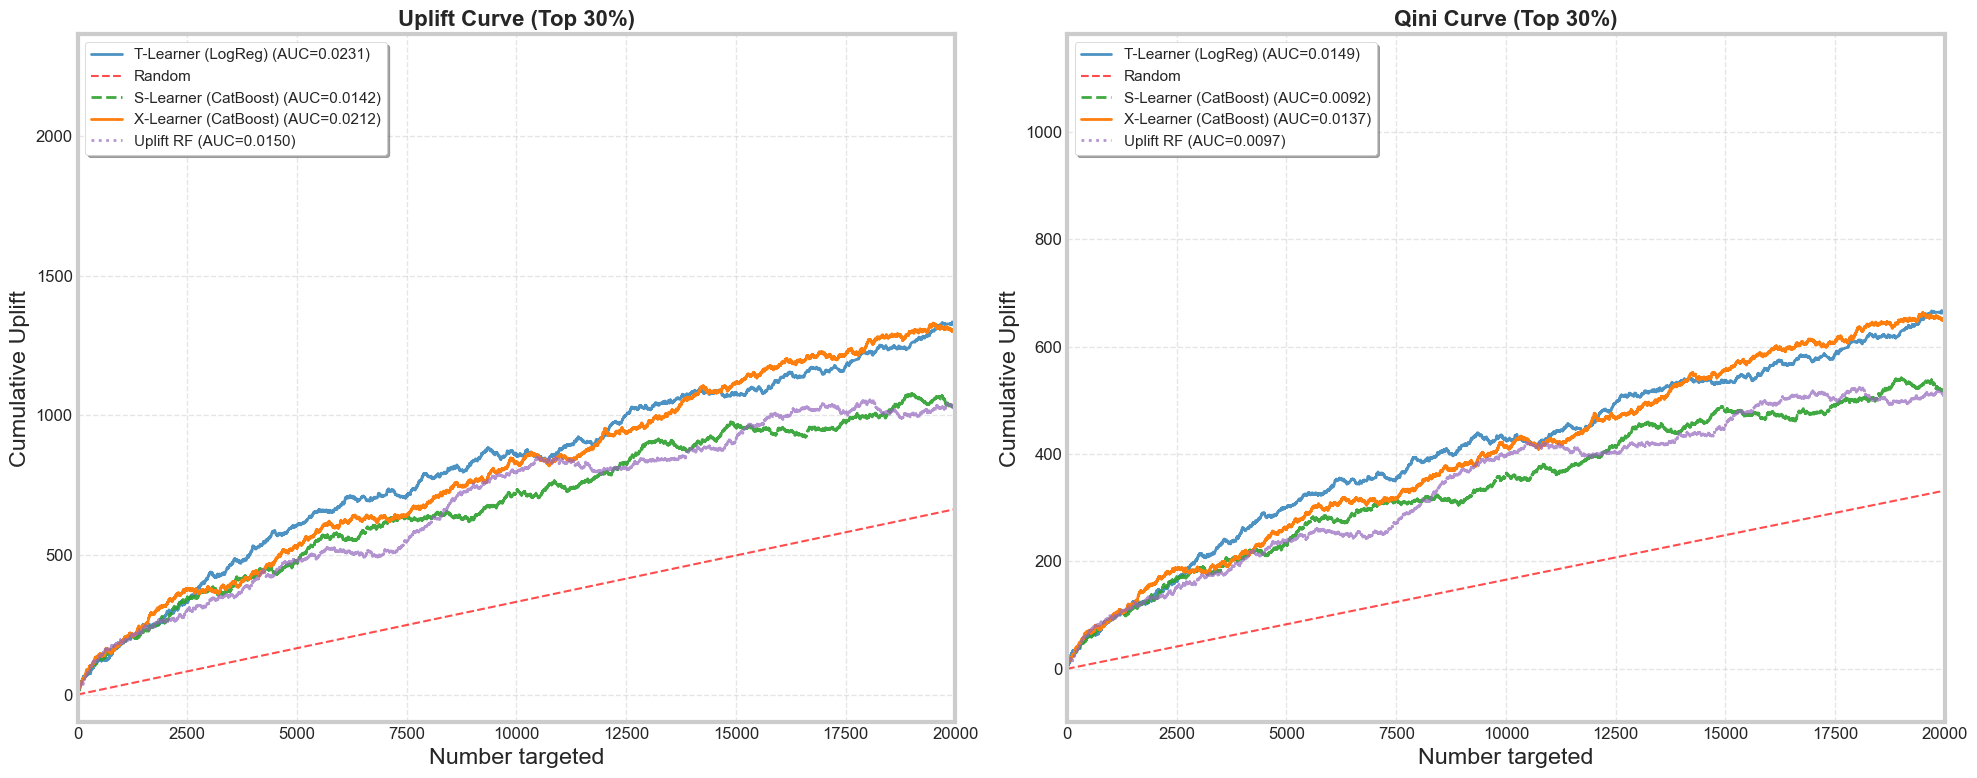

In [23]:
TOP_K_PERCENT = 0.3  # Посмотрим только на топ-30% базы
max_x = int(len(last_fold_y) * TOP_K_PERCENT)

model_colors = {
    "T-Learner (LogReg)": "#1f77b4",
    "S-Learner (CatBoost)": "#2ca02c",
    "X-Learner (CatBoost)": "#ff7f0e",
    "Uplift RF": "#9467bd"
}

model_styles = {
    "T-Learner (LogReg)": {"ls": "-", "alpha": 0.8},
    "S-Learner (CatBoost)": {"ls": "--", "alpha": 0.9},
    "X-Learner (CatBoost)": {"ls": "-", "alpha": 1.0},
    "Uplift RF": {"ls": ":", "alpha": 0.7}
}

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for model_name, preds in last_fold_preds.items():
    style = model_styles.get(model_name, {"ls": "-", "lw": 2, "alpha": 0.8})
    color = model_colors.get(model_name)
    
    # Uplift Curve
    plot_uplift_curve(last_fold_y, preds, last_fold_t, 
                      name=model_name, ax=axes[0], color=color, 
                      perfect=False, **style)

    # Qini Curve
    plot_qini_curve(last_fold_y, preds, last_fold_t, 
                    name=model_name, ax=axes[1], color=color, 
                    perfect=False, **style)

axes[0].set_title("Uplift Curve (Top 30%)", fontsize=16, fontweight='bold')
axes[1].set_title("Qini Curve (Top 30%)", fontsize=16, fontweight='bold')

for ax in axes:
    ax.set_xlim(0, max_x)
    ax.set_ylim(bottom=-100)
    
    ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()

Графики подтверждают, что:

* T-Learner и X-Learner показывают лучший и почти идентичный результат.
* Все модели стабильно выше Random-линии, что подтверждает пользу калибровки и новых фичей.
* S-Learner и Uplift RF показывают заметно меньший инкрементальный эффект.
* Основной прирост сосредоточен в начале списка (первые 5-7 тыс. клиентов), далее эффективность воздействия снижается.

Посмотрим на значимость признаков X-learner'а:

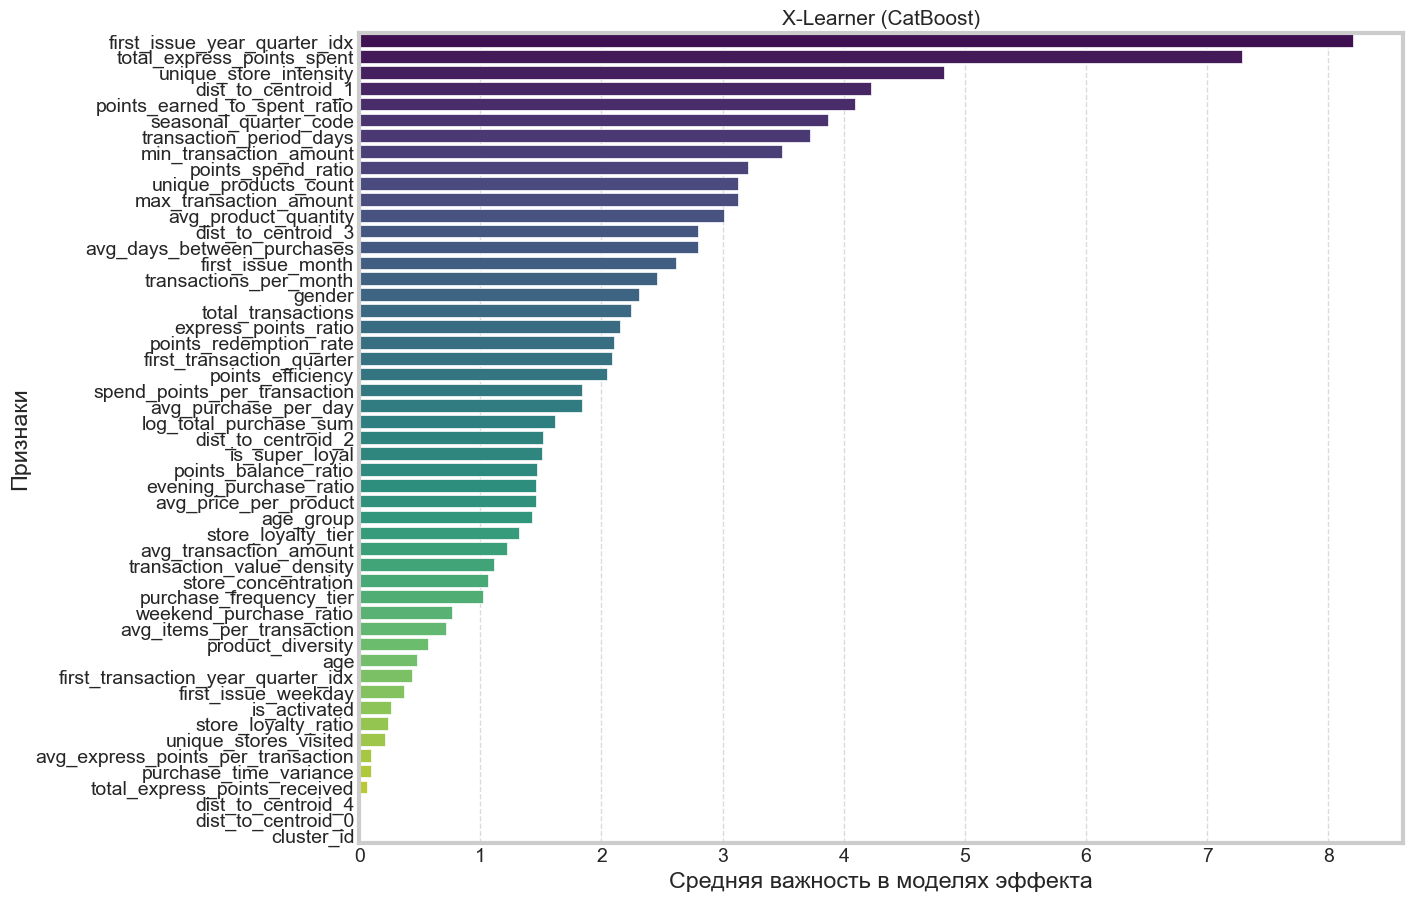

In [27]:
all_features = num_cols_cl + cat_cols_cl

# Извлекаем важность признаков из двух моделей эффекта (Regressors)
# Усредняем их, так как обе отвечают за предсказание аплифта
fi0 = x_learner.model_tau_0.get_feature_importance()
fi1 = x_learner.model_tau_1.get_feature_importance()
avg_importance = (fi0 + fi1) / 2

importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': avg_importance
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')

plt.title("X-Learner (CatBoost)", fontsize=15)
plt.xlabel("Средняя важность в моделях эффекта")
plt.ylabel("Признаки")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [28]:
cols_to_analyze = [c for c in num_cols_cl if c in X_train_clust.columns]

cluster_summary = X_train_clust.groupby('cluster_id')[cols_to_analyze].mean()
cluster_summary['size'] = X_train_clust['cluster_id'].value_counts()
cluster_summary['size_pct'] = (cluster_summary['size'] / len(X_train_clust) * 100).round(1)

print("Интерпретация кластеров (средние значения):")
display(cluster_summary.sort_values(by='size', ascending=False).style.background_gradient(cmap='YlGnBu', axis=0))

Интерпретация кластеров (средние значения):


,first_issue_month,first_issue_weekday,first_issue_year_quarter_idx,total_transactions,avg_transaction_amount,max_transaction_amount,min_transaction_amount,total_express_points_received,total_express_points_spent,avg_express_points_per_transaction,points_earned_to_spent_ratio,unique_products_count,avg_product_quantity,transaction_period_days,first_transaction_year_quarter_idx,unique_stores_visited,store_loyalty_ratio,weekend_purchase_ratio,evening_purchase_ratio,store_concentration,product_diversity,avg_price_per_product,avg_days_between_purchases,express_points_ratio,purchase_time_variance,points_redemption_rate,points_efficiency,avg_purchase_per_day,transactions_per_month,points_spend_ratio,points_balance_ratio,unique_store_intensity,log_total_purchase_sum,seasonal_quarter_code,avg_items_per_transaction,spend_points_per_transaction,transaction_value_density,is_super_loyal,age,is_activated,dist_to_centroid_0,dist_to_centroid_1,dist_to_centroid_2,dist_to_centroid_3,dist_to_centroid_4,size,size_pct
cluster_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,7.407280,2.964960,8072.574962,18.300929,428.009004,1096.640028,102.784439,0.014690,9.770555,0.000656,26.007611,66.763145,1.223154,99.714042,8076.000929,3.812011,0.612807,0.288556,0.052389,0.612807,0.639284,59.798201,9.540488,0.000096,2.818234,0.834588,0.008143,68.390244,5.365066,3.256166,26.007611,0.289026,8.562157,3.997213,6.950099,2.399303,0.087143,0.004191,45.809893,0.997861,4.757096,9.912926,15.235075,2.089481,15.985167,46290,34.700000
1,7.598839,2.905712,8072.452620,24.318920,463.671282,1190.056554,110.181046,0.012813,7.326460,0.000590,16.167652,84.078912,1.238046,102.294353,8076.000000,1.520693,0.975700,0.275738,0.042569,0.975700,0.570878,58.310448,8.012620,0.000065,2.602530,1.014542,0.008264,93.565959,6.916176,4.603001,16.167652,0.092463,8.866706,4.000000,7.697059,3.973771,0.087625,0.999470,49.186836,0.999912,12.423607,1.635878,11.799920,9.842888,7.275751,33949,25.500000
0,7.394444,2.873856,8071.181508,30.546071,633.747502,1772.619348,122.392196,4.167162,3.412714,0.199266,3.518865,120.546586,1.344037,105.390996,8076.007966,4.112432,0.660457,0.286488,0.043100,0.660457,0.534217,60.437176,5.853396,0.030806,2.817653,2.159509,0.009381,146.749361,8.573396,9.789321,3.518865,0.188160,9.403296,3.976103,9.962339,9.567092,0.105610,0.048785,46.778812,0.999049,2.133490,12.508554,14.233448,4.524569,17.360064,25233,18.900000
2,4.856749,3.000640,8074.341133,8.110099,533.882293,986.153187,256.285345,0.004433,3.510296,0.000210,21.994964,36.801034,1.260239,33.768227,8076.998424,1.969310,0.807095,0.292993,0.055716,0.807095,0.677452,60.309556,8.265820,0.000028,2.374711,0.394996,0.010048,225.450059,12.314895,2.493014,21.994964,0.446388,7.674248,1.004729,8.577041,1.708321,1.154316,0.510493,42.956158,0.764286,13.985524,11.815703,1.939285,15.207823,9.217496,20300,15.200000
4,8.109120,2.999341,8073.350422,10.317343,473.628260,970.696767,175.811936,0.006589,0.515156,0.000300,35.759935,41.064048,1.248365,92.404982,8076.000000,2.335266,0.754252,0.283287,0.041370,0.754252,0.668269,61.547727,23.791055,0.000102,2.513561,0.056381,0.008511,43.381711,3.229931,0.417655,35.759935,0.355778,7.975659,4.000000,7.532060,0.160736,0.088031,0.380601,46.302530,0.087902,17.183954,7.232436,9.075219,15.923636,1.157266,7588,5.700000


1. Группировка признаков по влиянию на Uplift:

* **Лояльность (Лидеры: `first_issue_year_quarter_idx`, `first_issue_month`)**
    Самый мощный сигнал. Модель видит огромную разницу в отклике в зависимости от того, когда клиент пришел в компанию. Это «якорные» признаки: лояльность, накопленная годами, определяет текущую реакцию на тритмент.
* **Механика баллов (Лидер: `total_express_points_spent`)**
    Вторая по важности группа. Те, кто активно тратит экспресс-баллы, - самая чувствительная к промо-акциям аудитория. Модель находит здесь убеждаемых, которые реагируют на дополнительный стимул.
* **Геометрия данных (Лидер: `dist_to_centroid_1`)**
    Тот факт, что расстояние до центроида **Кластера 1** (как раз самые лояльные) попало в топ-5, доказывает, что кластеризация нашла скрытую структуру, которую не описывают сырые фичи. Это критически важный инсайт для этапа DL - латентные представления (embeddings) будут работать эффективно.
* **Разнообразие и Интенсивность (`unique_store_intensity`, `points_earned_to_spent_ratio`)**
    Важен не только объем трат, но и то, насколько разнообразно ведет себя клиент. Сложное поведение (посещение разных магазинов) коррелирует с более высоким Uplift.

2. Портреты кластеров и их роль в модели:

| ID | Тип клиента | Размер | Роль в Uplift |
| :--- | :--- | :---: | :--- |
| **1** | **Core Loyals** | 25.5% | Самая предсказуемая группа. Имеют минимальное `dist_to_centroid_1`. Высочайшая лояльность (0.97). |
| **0** | **Whales** | 18.9% | Максимальные траты и частота. На них Uplift может быть ниже (купят и так), поэтому модель использует `dist_to_centroid_0` скорее для отсева. |
| **3** | **Balanced Active** | 34.7% | Самый массовый сегмент. Средние показатели, высокая готовность тратить баллы (0.83). |
| **4** | **Risky** | 5.7% | Минимальная активация (0.08) и редкие визиты. `dist_to_centroid_4` внизу списка, так как они почти не реагируют на тритмент. |


3. Инсайты для DL-моделей:

* **Embeddings вместо категорий:** Т.к. `first_issue_year_quarter_idx` и кластерные фичи доминируют, в нейросети стоит использовать обучаемые эмбеддинги для времени и ID кластеров.
* **Последовательности:** Высокая важность `avg_days_between_purchases` и динамики баллов намекает, что переход к анализу последовательностей транзакций (а не агрегатов) даст мощный буст.
* **Геометрический Loss:** Раз расстояния до центроидов так важны, в DL модели можно добавить дополнительную голову на предсказание кластера или латентного вектора клиента.